In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("../data/loans_clean.csv")

df.head()

,loan_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,purpose,addr_state,dti,fico_range_low,fico_range_high,open_acc,revol_bal,revol_util,total_acc,default_flag
0,68407277,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,...,debt_consolidation,PA,5.91,675.0,679.0,7.0,2765.0,29.7,13.0,0
1,68355089,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,...,small_business,SD,16.06,715.0,719.0,22.0,21470.0,19.2,38.0,0
2,68341763,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,...,home_improvement,IL,10.78,695.0,699.0,6.0,7869.0,56.2,18.0,0
3,68476807,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,...,major_purchase,PA,25.37,695.0,699.0,12.0,21929.0,64.5,35.0,0
4,68426831,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,...,debt_consolidation,GA,10.20,690.0,694.0,5.0,8822.0,68.4,6.0,0


In [4]:
df.columns.tolist()

['loan_id',
 'loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'addr_state',
 'dti',
 'fico_range_low',
 'fico_range_high',
 'open_acc',
 'revol_bal',
 'revol_util',
 'total_acc',
 'default_flag']

## Analysis 1: Credit Score vs Default

**Question:** Do borrowers with lower credit scores have higher observed default rates?

In [5]:
df["fico_avg"] = (
    df["fico_range_low"] + df["fico_range_high"]
) / 2

df[["fico_range_low", "fico_range_high", "fico_avg"]].head()

,fico_range_low,fico_range_high,fico_avg
0,675.0,679.0,677.0
1,715.0,719.0,717.0
2,695.0,699.0,697.0
3,695.0,699.0,697.0
4,690.0,694.0,692.0


In [6]:
df["fico_band"] = pd.cut(
    df["fico_avg"],
    bins=[0, 650, 700, 750, 800, 850],
    labels=["<650", "650-699", "700-749", "750-799", "800+"]
)

df[["fico_avg", "fico_band"]].head()

,fico_avg,fico_band
0,677.0,650-699
1,717.0,700-749
2,697.0,650-699
3,697.0,650-699
4,692.0,650-699


In [7]:
fico_default = (
    df.groupby("fico_band", observed=False)["default_flag"]
      .agg(["count", "mean"])
)

fico_default["default_rate"] = fico_default["mean"] * 100

fico_default

,count,mean,default_rate
fico_band,,,
<650,2,0.000000,0.000000
650-699,820825,0.235927,23.592727
700-749,417917,0.156651,15.665072
750-799,91158,0.093080,9.308015
800+,15448,0.064215,6.421543


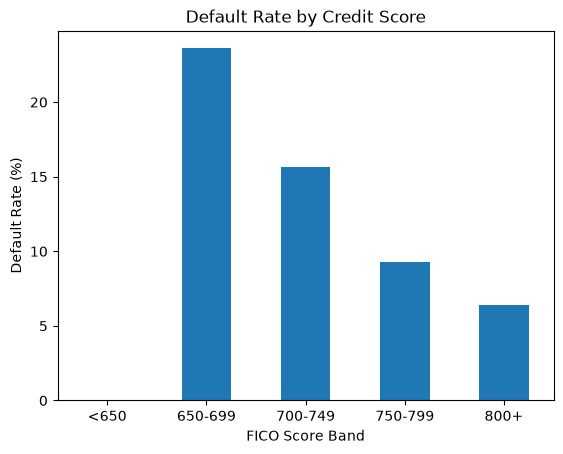

In [8]:
fico_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by Credit Score")
plt.xlabel("FICO Score Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

## Analysis 2: DTI vs Default

**Question:** Do borrowers with higher DTI have higher observed default rates?

In [9]:
df["dti_group"] = pd.cut(
    df["dti"],
    bins=[-np.inf, 20, 35, 50, np.inf],
    labels=["<20%", "20-35%", "35-50%", "50%+"]
)

df[["dti", "dti_group"]].head()

,dti,dti_group
0,5.91,<20%
1,16.06,<20%
2,10.78,<20%
3,25.37,20-35%
4,10.20,<20%


In [10]:
dti_default = (
    df.groupby("dti_group", observed=False)["default_flag"]
      .agg(["count", "mean"])
)

dti_default["default_rate"] = dti_default["mean"] * 100

dti_default

,count,mean,default_rate
dti_group,,,
<20%,808316,0.169449,16.944858
20-35%,501745,0.240728,24.072786
35-50%,32141,0.310538,31.053794
50%+,2774,0.286590,28.658976


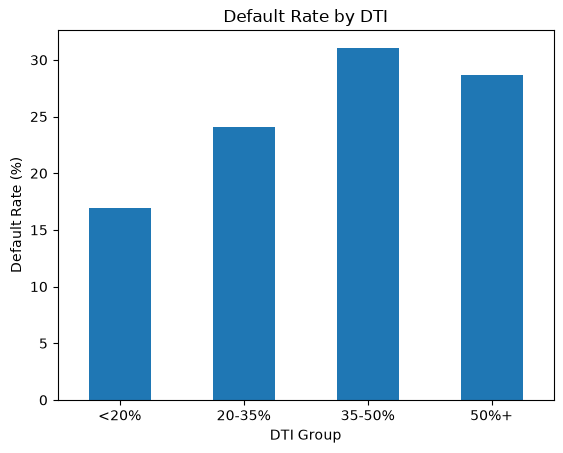

In [11]:
dti_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by DTI")
plt.xlabel("DTI Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

## Analysis 3: Income vs Default

**Question:** Do observed default rates differ across borrower income groups?

In [12]:
df["income_group"] = pd.cut(
    df["annual_inc"],
    bins=[0, 40000, 70000, 100000, 150000, np.inf],
    labels=["<$40K", "$40K-$70K", "$70K-$100K", "$100K-$150K", "$150K+"]
)

df[["annual_inc", "income_group"]].head()

,annual_inc,income_group
0,55000.0,$40K-$70K
1,65000.0,$40K-$70K
2,63000.0,$40K-$70K
3,104433.0,$100K-$150K
4,34000.0,<$40K


In [13]:
income_default = (
    df.groupby("income_group", observed=False)["default_flag"]
      .agg(["count", "mean"])
)

income_default["default_rate"] = income_default["mean"] * 100

income_default

,count,mean,default_rate
income_group,,,
<$40K,245589,0.236261,23.626058
$40K-$70K,526360,0.211580,21.157953
$70K-$100K,322993,0.185224,18.522383
$100K-$150K,178922,0.161780,16.177999
$150K+,71125,0.145786,14.578559


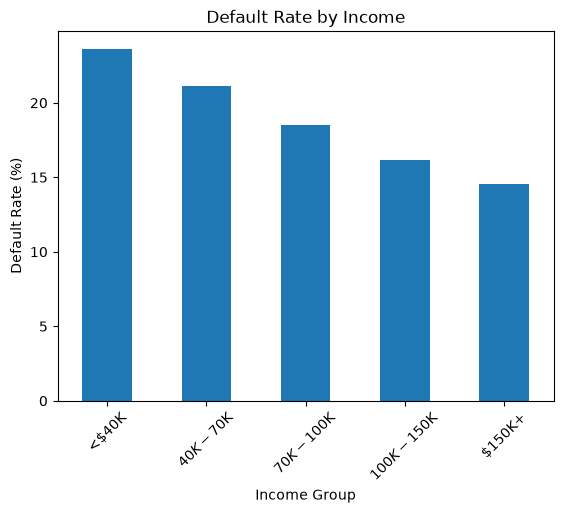

In [14]:
income_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by Income")
plt.xlabel("Income Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)

plt.show()

## Analysis 4: Interest Rate vs Default

**Question:** Do loans with higher interest rates have higher observed default rates?

In [15]:
df["interest_group"] = pd.cut(
    df["int_rate"],
    bins=[0, 8, 12, 16, 20, np.inf],
    labels=["<8%", "8-12%", "12-16%", "16-20%", "20%+"]
)

df[["int_rate", "interest_group"]].head()

,int_rate,interest_group
0,13.99,12-16%
1,11.99,8-12%
2,10.78,8-12%
3,22.45,20%+
4,13.44,12-16%


In [16]:
interest_default = (
    df.groupby("interest_group", observed=False)["default_flag"]
      .agg(["count", "mean"])
)

interest_default["default_rate"] = interest_default["mean"] * 100

interest_default

,count,mean,default_rate
interest_group,,,
<8%,208425,0.058251,5.825117
8-12%,382328,0.133409,13.340901
12-16%,419802,0.215656,21.565643
16-20%,227663,0.312800,31.280006
20%+,107132,0.407964,40.796401


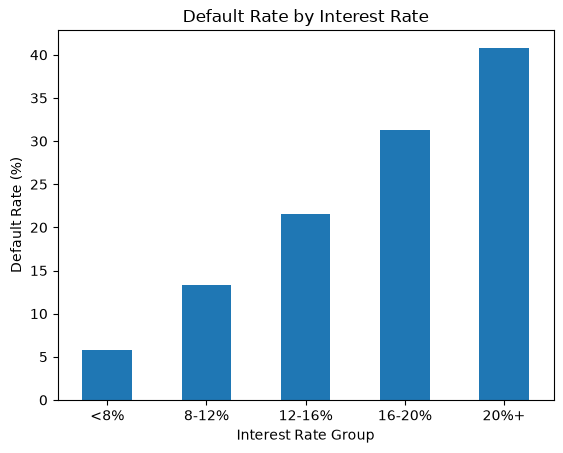

In [17]:
interest_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by Interest Rate")
plt.xlabel("Interest Rate Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

## Analysis 5: Loan Purpose vs Default

**Question:** Which loan purposes have the highest observed default rates?

In [18]:
purpose_default = (
    df.groupby("purpose")["default_flag"]
      .agg(["count", "mean"])
)

purpose_default["default_rate"] = purpose_default["mean"] * 100

purpose_default.sort_values("default_rate", ascending=False)

,count,mean,default_rate
purpose,,,
small_business,15416,0.297094,29.709393
renewable_energy,933,0.236870,23.687031
moving,9480,0.233544,23.354430
house,7254,0.218914,21.891370
medical,15556,0.217858,21.785806
debt_consolidation,780342,0.211491,21.149060
other,77877,0.210422,21.042156
vacation,9065,0.191726,19.172642
major_purchase,29427,0.186054,18.605362


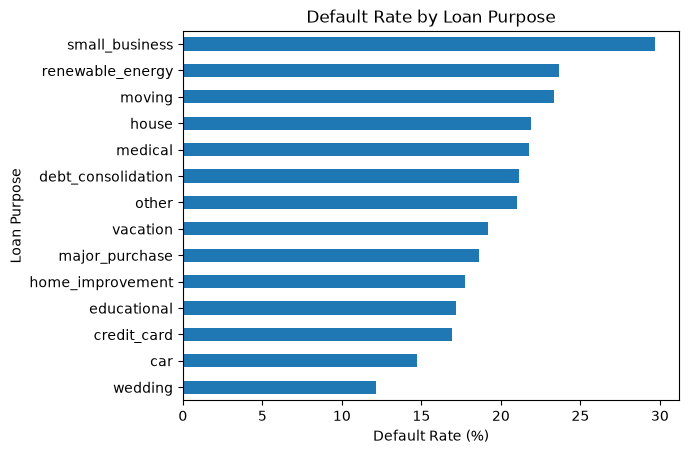

In [19]:
purpose_sorted = purpose_default.sort_values("default_rate")

purpose_sorted["default_rate"].plot(kind="barh")

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

plt.show()

## Key Findings

- **Credit Score:** Borrowers with lower FICO scores generally had higher observed default rates.
- **DTI:** Default rates generally increased as DTI increased, with the 35–50% DTI group showing the highest observed default rate.
- **Income:** Lower-income borrowers had higher observed default rates, while default rates decreased across higher income groups.
- **Interest Rate:** Higher interest-rate groups showed substantially higher observed default rates, increasing from about 5.8% for loans below 8% to about 40.8% for loans above 20%.
- **Loan Purpose:** Small-business loans had the highest observed default rate at approximately 29.7%.